In [1]:
print("Hello")

Hello


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation

class CoinTossSequence:
    def __init__(self, p_h=0.5, num_tosses=100):
        self.p_h = p_h  # probability of head
        self.num_tosses = num_tosses  # no of tosses
        self.animate_coin_toss_sequence()

    def toss_coin(self):
        all_tosses = []
        cumulative = [0]
        for toss_id in range(self.num_tosses):
            toss_value = np.random.choice(a=[0, 1], p=[1-self.p_h, self.p_h])
            all_tosses.append(toss_value)
            cumulative.append(cumulative[toss_id] + toss_value)
        cumulative = cumulative[1:]
        cumulative = [val / (i + 1) for i, val in enumerate(cumulative)]
        return np.array(all_tosses), np.array(cumulative)

    def animate_coin_toss_sequence(self):
        artists = []

        fig, ax = plt.subplots()
        ax.set_xlim(0, self.num_tosses)
        ax.set_ylim(0, 1)

        # 1. FIX: axhline ko loop se bahar nikaal diya (yeh background me constant rahegi)
        ax.axhline(y=self.p_h, color="y", linestyle="--")

        all_tosses, cumulative = self.toss_coin()

        for i in range(len(cumulative)):
            # 2. FIX: Har frame ke liye sirf badalti hui line plot hogi
            line = ax.plot(cumulative[:i+1], color="c")
            artists.append([line[0]])

        # 3. FIX: writer='pillow' add kiya taaki GIF smoothly save ho
        anim = ArtistAnimation(fig, artists, interval=100, blit=True)
        anim.save("coin.gif", writer='pillow', fps=10)
        
        # 4. FIX: Notebook me static image ko pop-up hone se rokne ke liye
        plt.close(fig)
        print("GIF successfully save ho gayi hai 'coin.gif' naam se!")

if __name__ == "__main__":
    coin = CoinTossSequence(p_h=0.8, num_tosses=100)

GIF successfully save ho gayi hai 'coin.gif' naam se!


import numpy as np
import matplotlib.pyplot as plt

# 1. Die Roll Simulate Karte Hain
# Man lo humne ludo ka chakka 50 baar ghumaya
num_rolls = 50
rolls = np.random.randint(1, 7, size=num_rolls)

# 2. Har Face (1 se 6) Kitni Baar Aaya, Wo Count Karenge
# np.bincount se hume har number ka count mil jayega
counts = np.bincount(rolls, minlength=7)[1:] 

# 3. Graph Plotting (Same to Same image_ee6281.png jaisa)
fig, ax = plt.subplots(figsize=(6, 5))

# 'color="c"' se wahi cyan/teal color aayega jo image me hai
# width=0.4 se bars patle ho jayenge
ax.bar(range(1, 7), counts, color="c", width=0.4)

# Formatting (Axis limits aur labels lagana)
ax.set_xlim(0.5, 6.5)
ax.set_ylim(0, 30)  # Image me limits 0 se 25-30 tak hain
ax.set_xticks(range(1, 7))

# Grid lines wagera sab saaf rakhne ke liye normal show
plt.show()

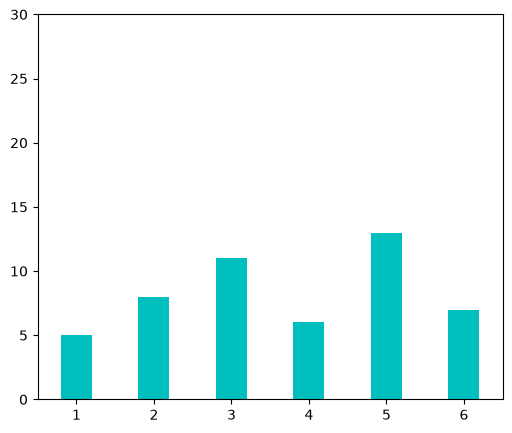

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Die Roll Simulate Karte Hain
# Man lo humne ludo ka chakka 50 baar ghumaya
num_rolls = 50
rolls = np.random.randint(1, 7, size=num_rolls)

# 2. Har Face (1 se 6) Kitni Baar Aaya, Wo Count Karenge
# np.bincount se hume har number ka count mil jayega
counts = np.bincount(rolls, minlength=7)[1:] 

# 3. Graph Plotting (Same to Same image_ee6281.png jaisa)
fig, ax = plt.subplots(figsize=(6, 5))

# 'color="c"' se wahi cyan/teal color aayega jo image me hai
# width=0.4 se bars patle ho jayenge
ax.bar(range(1, 7), counts, color="c", width=0.4)

# Formatting (Axis limits aur labels lagana)
ax.set_xlim(0.5, 6.5)
ax.set_ylim(0, 30)  # Image me limits 0 se 25-30 tak hain
ax.set_xticks(range(1, 7))

# Grid lines wagera sab saaf rakhne ke liye normal show
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation

class DiceRollAnimation:
    def __init__(self, num_rolls=150):
        self.num_rolls = num_rolls  # Total kitni baar dice fekna hai
        self.animate_dice()

    def simulate_rolls(self):
        # 1 se 6 tak random numbers generate karega
        return np.random.randint(1, 7, size=self.num_rolls)

    def animate_dice(self):
        artists = []
        fig, ax = plt.subplots(figsize=(6, 5))

        # Graph ke corners lock kar dete hain taaki animation hile na
        ax.set_xlim(0.5, 6.5)
        ax.set_ylim(0, self.num_rolls /import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation

class DiceRollAnimation:
    def __init__(self, num_rolls=150):
        self.num_rolls = num_rolls  # Total kitni baar dice fekna hai
        self.animate_dice()

    def simulate_rolls(self):
        # 1 se 6 tak random numbers generate karega
        return np.random.randint(1, 7, size=self.num_rolls)

    def animate_dice(self):
        artists = []
        fig, ax = plt.subplots(figsize=(6, 5))

        # Graph ke corners lock kar dete hain taaki animation hile na
        ax.set_xlim(0.5, 6.5)
        ax.set_ylim(0, self.num_rolls // 4)  # Ek safe height estimate
        ax.set_xticks(range(1, 7))

        all_rolls = self.simulate_rolls()

        # Frame-by-frame bars ko build karenge
        for i in range(1, len(all_rolls) + 1):
            # Har frame me ek naya roll add hoga
            current_rolls = all_rolls[:i]
            counts = np.bincount(current_rolls, minlength=7)[1:]

            # Bar plot banana (wahi same cyan color aur size)
            bars = ax.bar(range(1, 7), counts, color="c", width=0.4)
            
            # Matplotlib me bar container ko list me badal kar artists me dalna hota hai
            artists.append(list(bars))

        # GIF save karne ka chakkar
        anim = ArtistAnimation(fig, artists, interval=50, blit=True)
        anim.save("dice_roll.gif", writer='pillow', fps=20)
        
        plt.close(fig)
        print("Bhai, 'dice_roll.gif' ready hai! Jaakar folder check kar.")

if __name__ == "__main__":
    # 150 rolls ka mast animation banega
    DiceRollAnimation(num_rolls=150)import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation

class DiceRollAnimation:
    def __init__(self, num_rolls=150):
        self.num_rolls = num_rolls  # Total kitni baar dice fekna hai
        self.animate_dice()

    def simulate_rolls(self):
        # 1 se 6 tak random numbers generate karega
        return np.random.randint(1, 7, size=self.num_rolls)

    def animate_dice(self):
        artists = []
        fig, ax = plt.subplots(figsize=(6, 5))

        # Graph ke corners lock kar dete hain taaki animation hile na
        ax.set_xlim(0.5, 6.5)
        ax.set_ylim(0, self.num_rolls // 4)  # Ek safe height estimate
        ax.set_xticks(range(1, 7))

        all_rolls = self.simulate_rolls()

        # Frame-by-frame bars ko build karenge
        for i in range(1, len(all_rolls) + 1):
            # Har frame me ek naya roll add hoga
            current_rolls = all_rolls[:i]
            counts = np.bincount(current_rolls, minlength=7)[1:]

            # Bar plot banana (wahi same cyan color aur size)
            bars = ax.bar(range(1, 7), counts, color="c", width=0.4)
            
            # Matplotlib me bar container ko list me badal kar artists me dalna hota hai
            artists.append(list(bars))

        # GIF save karne ka chakkar
        anim = ArtistAnimation(fig, artists, interval=50, blit=True)
        anim.save("dice_roll.gif", writer='pillow', fps=20)
        
        plt.close(fig)
        print("Bhai, 'dice_roll.gif' ready hai! Jaakar folder check kar.")

if __name__ == "__main__":
    # 150 rolls ka mast animation banega
    DiceRollAnimation(num_rolls=150)/ 4)  # Ek safe height estimate
        ax.set_xticks(range(1, 7))

        all_rolls = self.simulate_rolls()

        # Frame-by-frame bars ko build karenge
        for i in range(1, len(all_rolls) + 1):
            # Har frame me ek naya roll add hoga
            current_rolls = all_rolls[:i]
            counts = np.bincount(current_rolls, minlength=7)[1:]

            # Bar plot banana (wahi same cyan color aur size)
            bars = ax.bar(range(1, 7), counts, color="c", width=0.4)
            
            # Matplotlib me bar container ko list me badal kar artists me dalna hota hai
            artists.append(list(bars))

        # GIF save karne ka chakkar
        anim = ArtistAnimation(fig, artists, interval=50, blit=True)
        anim.save("dice_roll.gif", writer='pillow', fps=20)
        
        plt.close(fig)
        print("Bhai, 'dice_roll.gif' ready hai! Jaakar folder check kar.")

if __name__ == "__main__":
    # 150 rolls ka mast animation banega
    DiceRollAnimation(num_rolls=150)

Bhai, 'dice_roll.gif' ready hai! Jaakar folder check kar.
